In [1]:
# The purpose of this project is to:
# investigate the column density of mixing ratios 
# of 5 different cases ranging from e=0.0167 to e=0.4 for constant zero obliquity

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

In [2]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']


# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0.001/atm/hist/')

# define specific path
          

Path_H2O        = []
Path_O3         = []

Path_ch4vmr     = []
Path_co2vmr     = []

Path_CLDHGH     = []


for i in range(len(data_dir_file)):
          
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0.nc')
    Path_O3.append(data_dir_file[i]+'O3_'+ e_range[i] +'_obl0.nc')
    Path_ch4vmr.append(data_dir_file[i]+'ch4vmr_'+ e_range[i] +'_obl0.nc')
    Path_co2vmr.append(data_dir_file[i]+'co2vmr_'+ e_range[i] +'_obl0.nc')
    Path_CLDHGH.append(data_dir_file[i]+'CLDHGH_'+ e_range[i] +'_obl0.nc')

# Import data

# each file has 5 case elements

H2O_obl0          =[]
O3_obl0           =[]
ch4vmr_obl0       =[]
co2vmr_obl0       =[]
CLDHGH_obl0       =[]


for i in range(len(e_range)):

          
    H2O_obl0.append(xr.open_mfdataset(Path_H2O[i]))
    O3_obl0.append(xr.open_mfdataset(Path_O3[i]))
    ch4vmr_obl0.append(xr.open_mfdataset(Path_ch4vmr[i]))
    co2vmr_obl0.append(xr.open_mfdataset(Path_co2vmr[i]))
    CLDHGH_obl0.append(xr.open_mfdataset(Path_CLDHGH[i]))


In [3]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    if (time == False):
        try:
            DS = DS.mean(dim='time')#take time mean
        except:
            print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [4]:
lat  = H2O_obl0[4]['lat']
lev  = H2O_obl0[4]['lev']
lon  = H2O_obl0[4]['lon']
H2O  = H2O_obl0[4]['H2O']  
ps   = H2O_obl0[4]['PS'].values
p0   = H2O_obl0[4]['P0'].values
hyai = H2O_obl0[4]['hyai'].values
hybi = H2O_obl0[4]['hybi'].values

nt = H2O_obl0[4]['time'].size
ny = H2O_obl0[4]['lat'].size
nz = H2O_obl0[4]['lev'].size
nx = H2O_obl0[4]['lon'].size

press = np.ndarray(nz, np.float32)
dp = np.ndarray(H2O.shape, np.float32)

In [5]:
for i in range(nt):  # at some time
    for j in range(ny): # at some location
        for k in range(nx):
            press = hyai * p0 + hybi * ps[i,j,k] # ps surface pressure at a point
            for iz in range(nz):# at some height, define dp 
                dp[i,iz,j,k] = (press[iz+1]-press[iz]) 

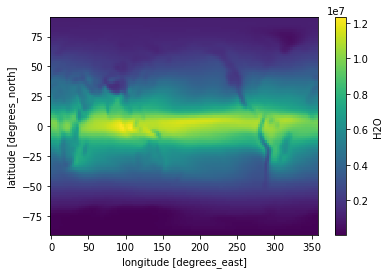

In [6]:
g = 9.8061
O2_mr = 0.21
N2_mr = 1-O2_mr
m_avg = ((28*N2_mr)+(O2_mr*32))*1.661*10**(-27)

H2O_mid = H2O * dp / (m_avg*g) # if you give 'g' here, every grid cell will be scaled down by g 
to_DU  = 1./2.6867e20
H2Ocol = np.sum(H2O_mid, axis = 1) * to_DU
H2Ocol = H2Ocol.mean(dim='time')

H2Ocol.plot()

In [7]:
# work everything under data array

xx=np.ndarray(H2O.shape, np.float32)

data = xx

lat  = H2O_obl0[4]['lat']
lev  = H2O_obl0[4]['lev']
lon  = H2O_obl0[4]['lon']
time = H2O_obl0[4]['time']

foo = xr.DataArray(data, coords=[time, lev, lat, lon], dims=["time", "lev", "lat", "lon"])

foo.values.fill(1)

In [8]:
ps_2   = H2O_obl0[4]['PS']
hybi_2 = H2O_obl0[4]['hybi']

p0_2  = H2O_obl0[4]['P0']
hyai_2 = H2O_obl0[4]['hyai']

press_2 = hyai_2 * p0_2 + hybi_2 * ps_2 # data array supports multiplication 


for iz in range(70):
    foo[:,iz,:,:]=(press_2[iz+1,:,:,:]-press_2[iz,:,:,:])


In [9]:
mid_step = (m_avg*g)/to_DU


H2O_foo = ((H2O * foo)/mid_step)


H2Ocol_foo = np.sum(H2O_foo, axis = 1)

H2Ocol_foo = H2Ocol_foo.mean(dim='time')


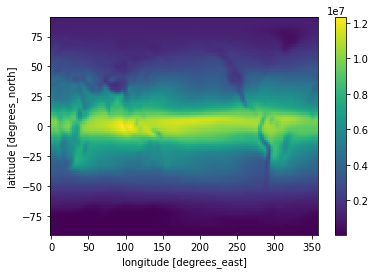

In [11]:
H2Ocol_foo.plot.imshow()

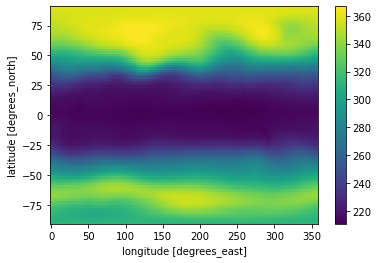

In [12]:
# work everything under data array
O3 = O3_obl0[4]['O3'] 

xx_O3=np.ndarray(O3.shape, np.float32)

data_O3 = xx_O3

lat_O3  = O3_obl0[4]['lat']
lev_O3  = O3_obl0[4]['lev']
lon_O3  = O3_obl0[4]['lon']
time_O3 = O3_obl0[4]['time']

foo_O3 = xr.DataArray(data_O3, coords=[time_O3, lev_O3, lat_O3, lon_O3], dims=["time", "lev", "lat", "lon"])

foo_O3.values.fill(1)

ps_2_O3   = O3_obl0[4]['PS']
hybi_2_O3 = O3_obl0[4]['hybi']

p0_2_O3  = O3_obl0[4]['P0']
hyai_2_O3 = O3_obl0[4]['hyai']

press_2_O3 = hyai_2_O3 * p0_2_O3 + hybi_2_O3 * ps_2_O3 # data array supports multiplication 


for iz in range(70):
    foo_O3[:,iz,:,:]=(press_2_O3[iz+1,:,:,:]-press_2_O3[iz,:,:,:])
    
mid_step = (m_avg*g)/to_DU


O3_foo = ((O3 * foo)/mid_step)


O3col_foo = np.sum(O3_foo, axis = 1)

O3col_foo = O3col_foo.mean(dim='time')

O3col_foo.plot.imshow()


In [ ]:

#%% define ozone column calculation function

def O3_col(ds, time = False, O2_mr = 0.21, lon = True):
    
    g = 9.80616           # gravity acceleration (cm/sec2)
    
    to_DU = 1./2.6867e20  # convert colunm density / cm^2 to Dobson units
    
    N2_mr = 1-O2_mr       # nitrogen mixing ratio
    
    m_avg = ((28*N2_mr)+(O2_mr*32))*1.661e-27 
                          # average weight of atmosphere
                          # calcualte column integrals 
    O3 = ds['O3']         # variables to calcualate hybrid pressure on model interfaces
    ps = ds['PS'].values  # surface pressure
    p0 = ds['P0'].values
    hyai = ds['hyai'].values
    hybi = ds['hybi'].values
    dp = np.ndarray(O3.shape, np.float32)
    
    nt = 1
    try:
        nt = ds['time'].size
    except:
        nt = 0
        
    ny = ds['lat'].size
    nz = ds['lev'].size
    nx = ds['lon'].size
    press = np.ndarray(nz, np.float32)

    
    if (nt > 0):
        for i in range(nt):
            for j in range(ny):
                for k in range(nx):
                    press = hyai * p0 + hybi * ps[i,j,k]
                    for iz in range(nz):
                        dp[i,iz,j,k] = (press[iz+1]-press[iz]) 
    else:
        for j in range(ny):
            for k in range(nx):
                press = hyai * p0 + hybi * ps[j,k]
                for iz in range(nz):
                    dp[iz,j,k] = (press[iz+1]-press[iz])
                    
    #calcualte column integrals 
    O3_mid = O3 * dp / (m_avg*g)
    
    o3col = np.sum(O3_mid, axis = 1) * to_DU           # convert to DU
                                                   # integrate by summing small chunks
    if (lon == False):
        
        o3col  = o3col.mean(dim='lon')
        
    if (time == False):
        
        try:
            o3col  = o3col.mean(dim='time')
        except:
            o3col  = o3col
    print('O3 columns calculated')
    return o3col